#### remember taker vs maker strat

we need to pick, size of our trades, entry/exit signal, leverage (borrowing money)

In [2]:
import polars as pl
import numpy as np
from datetime import datetime, timedelta
import random

import torch
import torch.nn as nn
import torch.optim as optim
import research

import altair as alt

import binance

In [3]:
import models
# TODO: retrain model with 3 features
model = models.LinearModel(3)

model.load_state_dict(torch.load('three_params_model_weights.pth', weights_only=True))
model.eval()

LinearModel(
  (linear): Linear(in_features=3, out_features=1, bias=True)
)

### Model Params

In [4]:
research.print_model_params(model)

linear.weight:
[[-0.10395038 -0.06726477  0.02827305]]
linear.bias:
[0.00067121]


### Mean Reversion

In [5]:
series = [-0.014, 0.011399, -0.012212, 0.01997, -0.01442, 0.01227]
mu = np.mean(series)
mean_reversion_df = pl.DataFrame({'log_return': series, 'mean': mu})
mean_reversion_df

log_return,mean
f64,f64
-0.014,0.000501
0.011399,0.000501
-0.012212,0.000501
0.01997,0.000501
-0.01442,0.000501
0.01227,0.000501


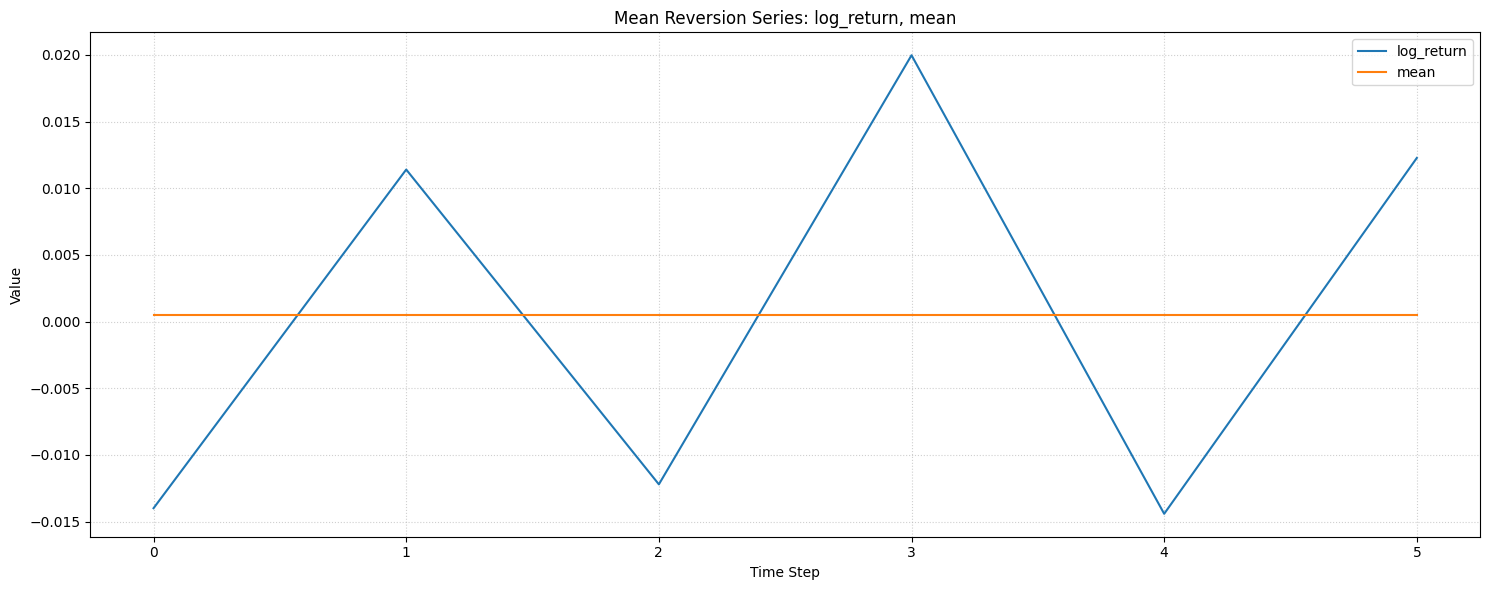

In [6]:
research.plot_multiple_lines(mean_reversion_df, ['log_return', 'mean'], 'Mean Reversion')

## Strategy development

### load time series

In [7]:
sym = 'BTCUSDT'
time_interval='12h'

ts = pl.read_csv(f"{sym}_{time_interval}_ohlc.csv", try_parse_dates=True).sort('datetime')
ts

datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2024-10-29 00:00:00,69939.9,71607.0,69733.0,71440.1
2024-10-29 12:00:00,71440.0,73660.0,70900.0,72739.5
2024-10-30 00:00:00,72739.5,72797.4,71931.1,71995.0
2024-10-30 12:00:00,71994.9,72984.9,71444.2,72349.0
2024-10-31 00:00:00,72349.0,72720.3,72030.5,72213.3
…,…,…,…,…
2025-10-07 12:00:00,124397.1,125098.0,120516.0,121286.5
2025-10-08 00:00:00,121286.6,123150.0,121005.3,122825.7
2025-10-08 12:00:00,122825.8,124170.6,121607.8,123237.5


#### add target and features


In [8]:
forecast_horizon = 1
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=3)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64
2024-10-29 00:00:00,69939.9,71607.0,69733.0,71440.1,null,null,null,null
2024-10-29 12:00:00,71440.0,73660.0,70900.0,72739.5,0.018025,null,null,null
2024-10-30 00:00:00,72739.5,72797.4,71931.1,71995.0,-0.010288,0.018025,null,null
2024-10-30 12:00:00,71994.9,72984.9,71444.2,72349.0,0.004905,-0.010288,0.018025,null
2024-10-31 00:00:00,72349.0,72720.3,72030.5,72213.3,-0.001877,0.004905,-0.010288,0.018025
…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,125098.0,120516.0,121286.5,-0.025324,-0.001858,0.003757,0.005933
2025-10-08 00:00:00,121286.6,123150.0,121005.3,122825.7,0.012611,-0.025324,-0.001858,0.003757
2025-10-08 12:00:00,122825.8,124170.6,121607.8,123237.5,0.003347,0.012611,-0.025324,-0.001858


In [9]:
test_size = 0.25
_, trades = research.timeseries_split(ts, test_size)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64
2025-07-15 12:00:00,117110.4,118499.8,115678.1,117738.5,0.005349,-0.022844,-0.013743,0.020259
2025-07-16 00:00:00,117738.6,119299.9,117017.1,118755.1,0.008597,0.005349,-0.022844,-0.013743
2025-07-16 12:00:00,118755.1,120100.0,118156.0,118590.7,-0.001385,0.008597,0.005349,-0.022844
2025-07-17 00:00:00,118590.7,119216.4,117663.6,117968.9,-0.005257,-0.001385,0.008597,0.005349
2025-07-17 12:00:00,117968.8,120951.5,117412.8,119176.6,0.010185,-0.005257,-0.001385,0.008597
…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,125098.0,120516.0,121286.5,-0.025324,-0.001858,0.003757,0.005933
2025-10-08 00:00:00,121286.6,123150.0,121005.3,122825.7,0.012611,-0.025324,-0.001858,0.003757
2025-10-08 12:00:00,122825.8,124170.6,121607.8,123237.5,0.003347,0.012611,-0.025324,-0.001858


#### strategy decision #1, entry/exit signal

In [10]:
# 1. time based. exit 12 hours later
# 2. predicate based. prediction, but until certain condition is satisfied, make prediction



##### add model predictions

In [11]:
target = 'close_log_return'
features = [f'{target}_lag_1', f'{target}_lag_2', f'{target}_lag_3']
trades = research.add_model_predictions(trades, model, features)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32
2025-07-15 12:00:00,117110.4,118499.8,115678.1,117738.5,0.005349,-0.022844,-0.013743,0.020259,0.004543
2025-07-16 00:00:00,117738.6,119299.9,117017.1,118755.1,0.008597,0.005349,-0.022844,-0.013743,0.001263
2025-07-16 12:00:00,118755.1,120100.0,118156.0,118590.7,-0.001385,0.008597,0.005349,-0.022844,-0.001228
2025-07-17 00:00:00,118590.7,119216.4,117663.6,117968.9,-0.005257,-0.001385,0.008597,0.005349,0.000388
2025-07-17 12:00:00,117968.8,120951.5,117412.8,119176.6,0.010185,-0.005257,-0.001385,0.008597,0.001554
…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,125098.0,120516.0,121286.5,-0.025324,-0.001858,0.003757,0.005933,0.000779
2025-10-08 00:00:00,121286.6,123150.0,121005.3,122825.7,0.012611,-0.025324,-0.001858,0.003757,0.003535
2025-10-08 12:00:00,122825.8,124170.6,121607.8,123237.5,0.003347,0.012611,-0.025324,-0.001858,0.001011


##### add directional signal

In [12]:
trades = trades.with_columns(pl.col('y_hat').sign().alias('dir_signal'))
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32
2025-07-15 12:00:00,117110.4,118499.8,115678.1,117738.5,0.005349,-0.022844,-0.013743,0.020259,0.004543,1.0
2025-07-16 00:00:00,117738.6,119299.9,117017.1,118755.1,0.008597,0.005349,-0.022844,-0.013743,0.001263,1.0
2025-07-16 12:00:00,118755.1,120100.0,118156.0,118590.7,-0.001385,0.008597,0.005349,-0.022844,-0.001228,-1.0
2025-07-17 00:00:00,118590.7,119216.4,117663.6,117968.9,-0.005257,-0.001385,0.008597,0.005349,0.000388,1.0
2025-07-17 12:00:00,117968.8,120951.5,117412.8,119176.6,0.010185,-0.005257,-0.001385,0.008597,0.001554,1.0
…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,125098.0,120516.0,121286.5,-0.025324,-0.001858,0.003757,0.005933,0.000779,1.0
2025-10-08 00:00:00,121286.6,123150.0,121005.3,122825.7,0.012611,-0.025324,-0.001858,0.003757,0.003535,1.0
2025-10-08 12:00:00,122825.8,124170.6,121607.8,123237.5,0.003347,0.012611,-0.025324,-0.001858,0.001011,1.0


#### calc trade log return

In [13]:
trades= trades.with_columns(
    (pl.col('close_log_return') * pl.col('dir_signal')).alias('trade_log_return')
)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64
2025-07-15 12:00:00,117110.4,118499.8,115678.1,117738.5,0.005349,-0.022844,-0.013743,0.020259,0.004543,1.0,0.005349
2025-07-16 00:00:00,117738.6,119299.9,117017.1,118755.1,0.008597,0.005349,-0.022844,-0.013743,0.001263,1.0,0.008597
2025-07-16 12:00:00,118755.1,120100.0,118156.0,118590.7,-0.001385,0.008597,0.005349,-0.022844,-0.001228,-1.0,0.001385
2025-07-17 00:00:00,118590.7,119216.4,117663.6,117968.9,-0.005257,-0.001385,0.008597,0.005349,0.000388,1.0,-0.005257
2025-07-17 12:00:00,117968.8,120951.5,117412.8,119176.6,0.010185,-0.005257,-0.001385,0.008597,0.001554,1.0,0.010185
…,…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,125098.0,120516.0,121286.5,-0.025324,-0.001858,0.003757,0.005933,0.000779,1.0,-0.025324
2025-10-08 00:00:00,121286.6,123150.0,121005.3,122825.7,0.012611,-0.025324,-0.001858,0.003757,0.003535,1.0,0.012611
2025-10-08 12:00:00,122825.8,124170.6,121607.8,123237.5,0.003347,0.012611,-0.025324,-0.001858,0.001011,1.0,0.003347


#### calc cumulative trade log return

In [14]:
trades = trades.with_columns(
    pl.col('trade_log_return').cum_sum().alias('cum_trade_log_return')
)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64
2025-07-15 12:00:00,117110.4,118499.8,115678.1,117738.5,0.005349,-0.022844,-0.013743,0.020259,0.004543,1.0,0.005349,0.005349
2025-07-16 00:00:00,117738.6,119299.9,117017.1,118755.1,0.008597,0.005349,-0.022844,-0.013743,0.001263,1.0,0.008597,0.013946
2025-07-16 12:00:00,118755.1,120100.0,118156.0,118590.7,-0.001385,0.008597,0.005349,-0.022844,-0.001228,-1.0,0.001385,0.015332
2025-07-17 00:00:00,118590.7,119216.4,117663.6,117968.9,-0.005257,-0.001385,0.008597,0.005349,0.000388,1.0,-0.005257,0.010075
2025-07-17 12:00:00,117968.8,120951.5,117412.8,119176.6,0.010185,-0.005257,-0.001385,0.008597,0.001554,1.0,0.010185,0.02026
…,…,…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,125098.0,120516.0,121286.5,-0.025324,-0.001858,0.003757,0.005933,0.000779,1.0,-0.025324,0.227467
2025-10-08 00:00:00,121286.6,123150.0,121005.3,122825.7,0.012611,-0.025324,-0.001858,0.003757,0.003535,1.0,0.012611,0.240078
2025-10-08 12:00:00,122825.8,124170.6,121607.8,123237.5,0.003347,0.012611,-0.025324,-0.001858,0.001011,1.0,0.003347,0.243425


#### display equity curve (log space)

In [15]:
research.plot_column(trades, 'cum_trade_log_return')

alt.Chart(...)

## Strategy decision #2: Trade sizing

In [16]:
#1. constant trade size
#2. compounding trade size

##### constant sizing

In [17]:
capital = 100
ratio = 1.0
trade_value = ratio * capital

# entry trade value and exit trade value
trades = trades.with_columns(
    pl.lit(trade_value).alias('entry_trade_value'),
    (trade_value * pl.col('trade_log_return').exp()).alias('exit_trade_value'),
    (trade_value / pl.col('open')).alias('trade_qty'),
).with_columns(
    (pl.col('trade_qty') * pl.col('dir_signal')).alias('signed_trade_qty')
)
trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty
datetime[μs],f64,f64,f64,f32,f64,f64,f64
2025-07-15 12:00:00,117110.4,117738.5,0.005349,0.004543,100.0,100.536332,0.000854
2025-07-16 00:00:00,117738.6,118755.1,0.008597,0.001263,100.0,100.863439,0.000849
2025-07-16 12:00:00,118755.1,118590.7,0.001385,-0.001228,100.0,100.138628,-0.000842
2025-07-17 00:00:00,118590.7,117968.9,-0.005257,0.000388,100.0,99.475676,0.000843
2025-07-17 12:00:00,117968.8,119176.6,0.010185,0.001554,100.0,101.023744,0.000848
…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,121286.5,-0.025324,0.000779,100.0,97.499381,0.000804
2025-10-08 00:00:00,121286.6,122825.7,0.012611,0.003535,100.0,101.269061,0.000824
2025-10-08 12:00:00,122825.8,123237.5,0.003347,0.001011,100.0,100.335272,0.000814


#### add trade gross profit and loss

In [18]:
trades = trades.with_columns(
    (pl.col('exit_trade_value') - pl.col('entry_trade_value')).alias('trade_gross_pnl')
)

trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64
2025-07-15 12:00:00,117110.4,117738.5,0.005349,0.004543,100.0,100.536332,0.000854,0.536332
2025-07-16 00:00:00,117738.6,118755.1,0.008597,0.001263,100.0,100.863439,0.000849,0.863439
2025-07-16 12:00:00,118755.1,118590.7,0.001385,-0.001228,100.0,100.138628,-0.000842,0.138628
2025-07-17 00:00:00,118590.7,117968.9,-0.005257,0.000388,100.0,99.475676,0.000843,-0.524324
2025-07-17 12:00:00,117968.8,119176.6,0.010185,0.001554,100.0,101.023744,0.000848,1.023744
…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,121286.5,-0.025324,0.000779,100.0,97.499381,0.000804,-2.500619
2025-10-08 00:00:00,121286.6,122825.7,0.012611,0.003535,100.0,101.269061,0.000824,1.269061
2025-10-08 12:00:00,122825.8,123237.5,0.003347,0.001011,100.0,100.335272,0.000814,0.335272


#### Add transaction fees 

In [25]:
taker_fee = binance.TAKER_FEE
maker_fee = binance.MAKER_FEE

trades = trades.with_columns(
    (pl.col('entry_trade_value') * taker_fee + pl.col('exit_trade_value') * taker_fee).alias('taker_fee'),
    (pl.col('entry_trade_value') * maker_fee + pl.col('exit_trade_value') * maker_fee).alias('maker_fee')
)


trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl', 'maker_fee', 'taker_fee')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl,maker_fee,taker_fee
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64,f64,f64
2025-07-15 12:00:00,117110.4,117738.5,0.005349,0.004543,100.0,100.536332,0.000854,0.536332,0.090241,0.090241
2025-07-16 00:00:00,117738.6,118755.1,0.008597,0.001263,100.0,100.863439,0.000849,0.863439,0.090389,0.090389
2025-07-16 12:00:00,118755.1,118590.7,0.001385,-0.001228,100.0,100.138628,-0.000842,0.138628,0.090062,0.090062
2025-07-17 00:00:00,118590.7,117968.9,-0.005257,0.000388,100.0,99.475676,0.000843,-0.524324,0.089764,0.089764
2025-07-17 12:00:00,117968.8,119176.6,0.010185,0.001554,100.0,101.023744,0.000848,1.023744,0.090461,0.090461
…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,121286.5,-0.025324,0.000779,100.0,97.499381,0.000804,-2.500619,0.088875,0.088875
2025-10-08 00:00:00,121286.6,122825.7,0.012611,0.003535,100.0,101.269061,0.000824,1.269061,0.090571,0.090571
2025-10-08 12:00:00,122825.8,123237.5,0.003347,0.001011,100.0,100.335272,0.000814,0.335272,0.090151,0.090151


##### calc net trade pnl

In [26]:
trades = trades.with_columns(
    (pl.col('trade_gross_pnl') - pl.col('maker_fee')).alias('trade_net_maker_pnl'),
    (pl.col('trade_gross_pnl') - pl.col('taker_fee')).alias('trade_net_taker_pnl'),
)


trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl', 'trade_net_taker_pnl', 'trade_net_maker_pnl')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl,trade_net_taker_pnl,trade_net_maker_pnl
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64,f64,f64
2025-07-15 12:00:00,117110.4,117738.5,0.005349,0.004543,100.0,100.536332,0.000854,0.536332,0.44609,0.44609
2025-07-16 00:00:00,117738.6,118755.1,0.008597,0.001263,100.0,100.863439,0.000849,0.863439,0.77305,0.77305
2025-07-16 12:00:00,118755.1,118590.7,0.001385,-0.001228,100.0,100.138628,-0.000842,0.138628,0.048566,0.048566
2025-07-17 00:00:00,118590.7,117968.9,-0.005257,0.000388,100.0,99.475676,0.000843,-0.524324,-0.614088,-0.614088
2025-07-17 12:00:00,117968.8,119176.6,0.010185,0.001554,100.0,101.023744,0.000848,1.023744,0.933284,0.933284
…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,121286.5,-0.025324,0.000779,100.0,97.499381,0.000804,-2.500619,-2.589494,-2.589494
2025-10-08 00:00:00,121286.6,122825.7,0.012611,0.003535,100.0,101.269061,0.000824,1.269061,1.17849,1.17849
2025-10-08 12:00:00,122825.8,123237.5,0.003347,0.001011,100.0,100.335272,0.000814,0.335272,0.245121,0.245121


#### display equity curves for constant sizing

In [28]:
def equity_curve(capital, col_name, suffix):
    return (capital + (pl.col(col_name).cum_sum())).alias(f'equity_curve_{suffix}')

trades = trades.with_columns(
    equity_curve(capital, 'trade_net_taker_pnl', 'taker'),
    equity_curve(capital, 'trade_net_maker_pnl', 'maker'),
    equity_curve(capital, 'trade_gross_pnl', 'gross'),
)

trades.select('datetime', 'equity_curve_gross', 'equity_curve_taker', 'equity_curve_maker')

datetime,equity_curve_gross,equity_curve_taker,equity_curve_maker
datetime[μs],f64,f64,f64
2025-07-15 12:00:00,100.536332,100.44609,100.44609
2025-07-16 00:00:00,101.39977,101.219141,101.219141
2025-07-16 12:00:00,101.538398,101.267706,101.267706
2025-07-17 00:00:00,101.014074,100.653618,100.653618
2025-07-17 12:00:00,102.037818,101.586901,101.586901
…,…,…,…
2025-10-07 12:00:00,123.624693,108.404062,108.404062
2025-10-08 00:00:00,124.893754,109.582552,109.582552
2025-10-08 12:00:00,125.229026,109.827673,109.827673


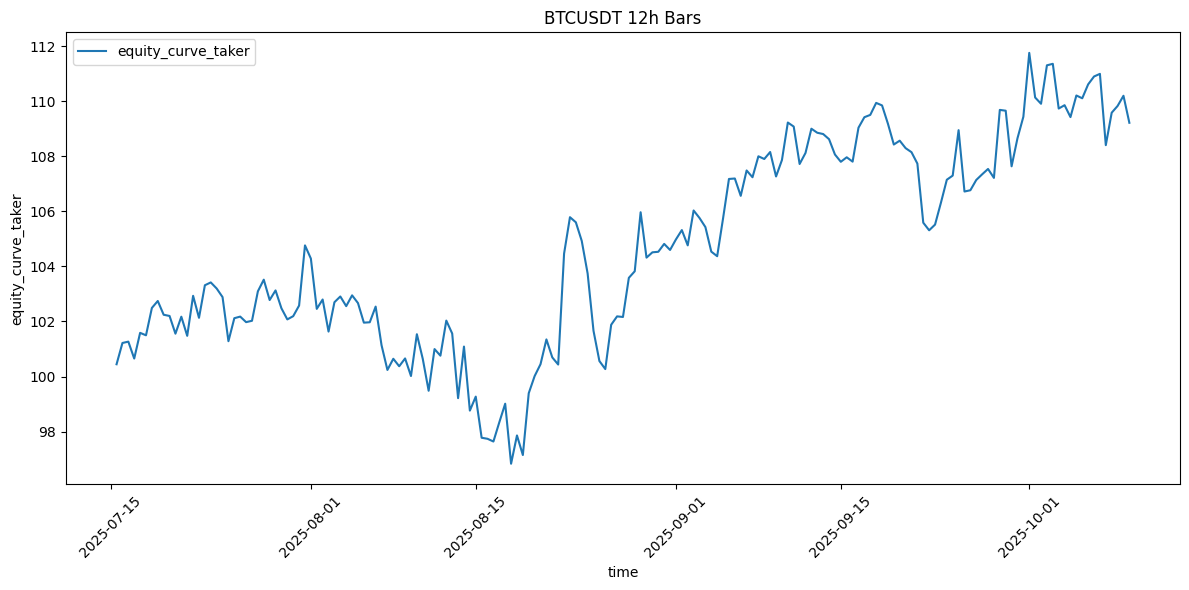

In [29]:
research.plot_static_timeseries(trades, sym, 'equity_curve_taker',time_interval)

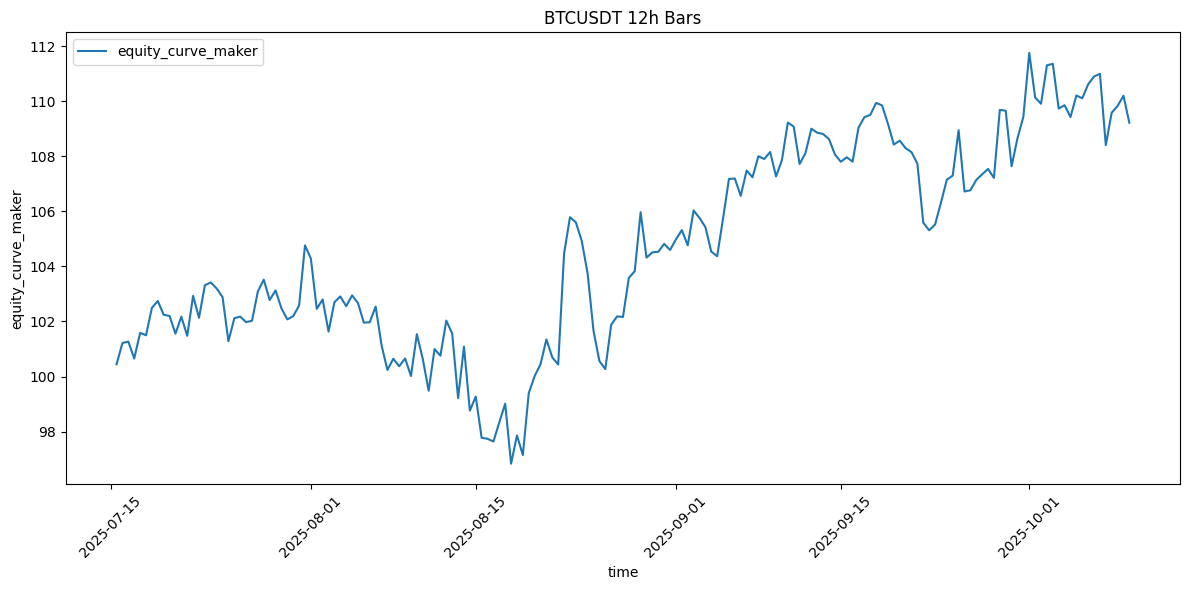

In [30]:
research.plot_static_timeseries(trades, sym, 'equity_curve_maker',time_interval)

### calculate total net return using constant sizing

In [ ]:
constant_sizing_net_return = trades['equity_curve_taker'][-1] / capital - 1
constant_sizing_net_return

0.09216639222435541

#### compounding trade sizing

reinvesting earnings basically.

- if you put in 100, and earn two, your next trade you would put in 102
- principle of time additivity

In [32]:
trades = trades.with_columns(
    ((pl.col('cum_trade_log_return').exp()) * capital).shift().fill_null(capital).alias('entry_trade_value'),
    ((pl.col('cum_trade_log_return').exp()) * capital).alias('exit_trade_value')
).with_columns(
    (pl.col('entry_trade_value') / pl.col('open') * pl.col('dir_signal')).alias('signed_trade_qty'),
    (pl.col('exit_trade_value') - pl.col('entry_trade_value')).alias('trade_gross_pnl'),
)

trades.select('datetime', 'open', 'close', 'trade_log_return', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl')

datetime,open,close,trade_log_return,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl
datetime[μs],f64,f64,f64,f64,f64,f64,f64
2025-07-15 12:00:00,117110.4,117738.5,0.005349,100.0,100.536332,0.000854,0.536332
2025-07-16 00:00:00,117738.6,118755.1,0.008597,100.536332,101.404401,0.000854,0.86807
2025-07-16 12:00:00,118755.1,118590.7,0.001385,101.404401,101.544976,-0.000854,0.140575
2025-07-17 00:00:00,118590.7,117968.9,-0.005257,101.544976,101.012551,0.000856,-0.532425
2025-07-17 12:00:00,117968.8,119176.6,0.010185,101.012551,102.046662,0.000856,1.03411
…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,121286.5,-0.025324,128.761487,125.541653,0.001035,-3.219834
2025-10-08 00:00:00,121286.6,122825.7,0.012611,125.541653,127.134854,0.001035,1.5932
2025-10-08 12:00:00,122825.8,123237.5,0.003347,127.134854,127.561101,0.001035,0.426247


##### add transaction fees

In [33]:
trades = research.add_tx_fees(trades, binance.MAKER_FEE, binance.TAKER_FEE)
trades.select('datetime', 'entry_trade_value', 'exit_trade_value', 'tx_fee_maker', 'tx_fee_taker')

datetime,entry_trade_value,exit_trade_value,tx_fee_maker,tx_fee_taker
datetime[μs],f64,f64,f64,f64
2025-07-15 12:00:00,100.0,100.536332,0.090241,0.090241
2025-07-16 00:00:00,100.536332,101.404401,0.090873,0.090873
2025-07-16 12:00:00,101.404401,101.544976,0.091327,0.091327
2025-07-17 00:00:00,101.544976,101.012551,0.091151,0.091151
2025-07-17 12:00:00,101.012551,102.046662,0.091377,0.091377
…,…,…,…,…
2025-10-07 12:00:00,128.761487,125.541653,0.114436,0.114436
2025-10-08 00:00:00,125.541653,127.134854,0.113704,0.113704
2025-10-08 12:00:00,127.134854,127.561101,0.114613,0.114613


#### add trade net pnl

In [34]:
trades = trades.with_columns(
    (pl.col('trade_gross_pnl') - pl.col('tx_fee_taker')).alias('trade_net_taker_pnl')
)

trades.select('datetime', 'open', 'close', 'close_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'trade_gross_pnl', 'trade_net_taker_pnl')

datetime,open,close,close_log_return,y_hat,entry_trade_value,exit_trade_value,trade_gross_pnl,trade_net_taker_pnl
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64
2025-07-15 12:00:00,117110.4,117738.5,0.005349,0.004543,100.0,100.536332,0.536332,0.44609
2025-07-16 00:00:00,117738.6,118755.1,0.008597,0.001263,100.536332,101.404401,0.86807,0.777196
2025-07-16 12:00:00,118755.1,118590.7,-0.001385,-0.001228,101.404401,101.544976,0.140575,0.049248
2025-07-17 00:00:00,118590.7,117968.9,-0.005257,0.000388,101.544976,101.012551,-0.532425,-0.623576
2025-07-17 12:00:00,117968.8,119176.6,0.010185,0.001554,101.012551,102.046662,1.03411,0.942734
…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,121286.5,-0.025324,0.000779,128.761487,125.541653,-3.219834,-3.334271
2025-10-08 00:00:00,121286.6,122825.7,0.012611,0.003535,125.541653,127.134854,1.5932,1.479496
2025-10-08 12:00:00,122825.8,123237.5,0.003347,0.001011,127.134854,127.561101,0.426247,0.311634


### Display equity curve (compounding)

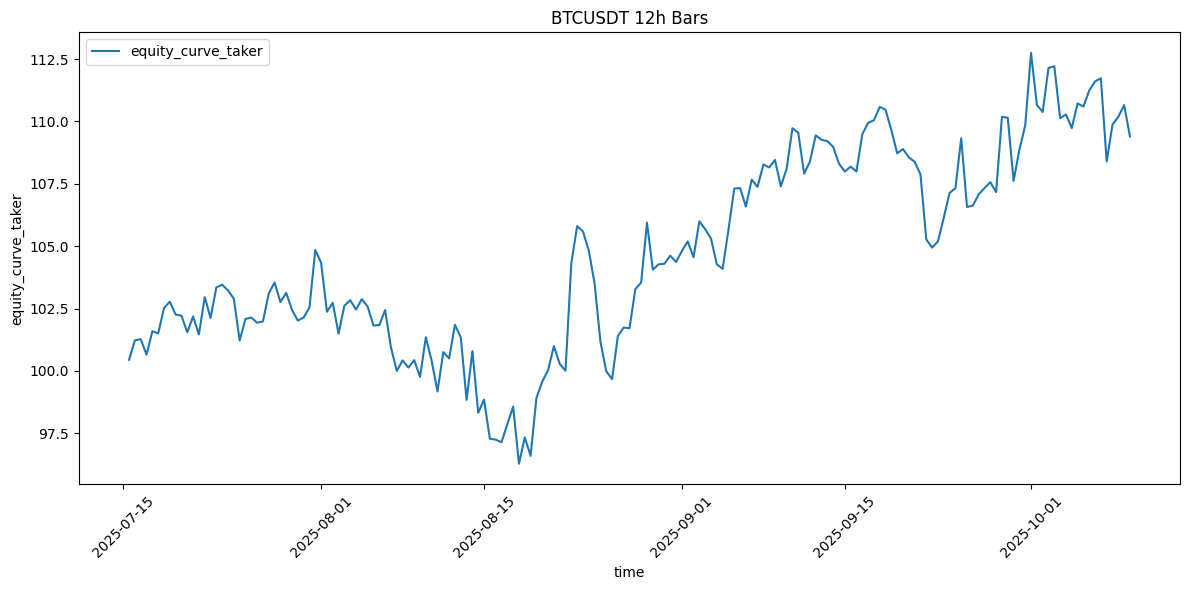

In [35]:
trades = research.add_equity_curve(trades, capital, 'trade_net_taker_pnl', 'taker')
research.plot_static_timeseries(trades, sym, 'equity_curve_taker', time_interval)

### calculate total net return for compounding trade sizing

In [37]:
compound_total_net_return = trades['equity_curve_taker'][-1] / capital - 1
compound_total_net_return

0.09398874749369845

In [40]:
constant_sizing_net_return

0.09216639222435541

In [42]:
np.round(compound_total_net_return - constant_sizing_net_return, 3)

np.float64(0.002)

### Strategy decision #3, leverage

borrowing money?


In [44]:
leverage = 4
trades = research.add_compounding_trades(trades, capital, leverage, maker_fee, taker_fee)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return,entry_trade_value,exit_trade_value,trade_qty,signed_trade_qty,trade_gross_pnl,taker_fee,maker_fee,trade_net_maker_pnl,trade_net_taker_pnl,equity_curve_taker,equity_curve_maker,equity_curve_gross,tx_fee_maker,tx_fee_taker
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-07-15 12:00:00,117110.4,118499.8,115678.1,117738.5,0.005349,-0.022844,-0.013743,0.020259,0.004543,1.0,0.005349,0.005349,400.0,402.145326,0.000854,0.003416,2.145326,0.090241,0.090241,1.784361,1.784361,101.784361,101.784361,102.145326,0.360965,0.360965
2025-07-16 00:00:00,117738.6,119299.9,117017.1,118755.1,0.008597,0.005349,-0.022844,-0.013743,0.001263,1.0,0.008597,0.013946,402.145326,405.617605,0.000849,0.003416,3.472279,0.090389,0.090389,3.108786,3.108786,104.893147,104.893147,105.617605,0.363493,0.363493
2025-07-16 12:00:00,118755.1,120100.0,118156.0,118590.7,-0.001385,0.008597,0.005349,-0.022844,-0.001228,-1.0,0.001385,0.015332,405.617605,406.179905,0.000842,-0.003416,0.5623,0.090062,0.090062,0.196991,0.196991,105.090138,105.090138,106.179905,0.365309,0.365309
2025-07-17 00:00:00,118590.7,119216.4,117663.6,117968.9,-0.005257,-0.001385,0.008597,0.005349,0.000388,1.0,-0.005257,0.010075,406.179905,404.050205,0.000843,0.003425,-2.1297,0.089764,0.089764,-2.494304,-2.494304,102.595834,102.595834,104.050205,0.364604,0.364604
2025-07-17 12:00:00,117968.8,120951.5,117412.8,119176.6,0.010185,-0.005257,-0.001385,0.008597,0.001554,1.0,0.010185,0.02026,404.050205,408.186646,0.000848,0.003425,4.136441,0.090461,0.090461,3.770935,3.770935,106.366768,106.366768,108.186646,0.365507,0.365507
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,125098.0,120516.0,121286.5,-0.025324,-0.001858,0.003757,0.005933,0.000779,1.0,-0.025324,0.227467,515.045949,502.166612,0.000804,0.00414,-12.879337,0.088875,0.088875,-13.337082,-13.337082,133.571784,133.571784,202.166612,0.457746,0.457746
2025-10-08 00:00:00,121286.6,123150.0,121005.3,122825.7,0.012611,-0.025324,-0.001858,0.003757,0.003535,1.0,0.012611,0.240078,502.166612,508.539414,0.000824,0.00414,6.372802,0.090571,0.090571,5.917984,5.917984,139.489769,139.489769,208.539414,0.454818,0.454818
2025-10-08 12:00:00,122825.8,124170.6,121607.8,123237.5,0.003347,0.012611,-0.025324,-0.001858,0.001011,1.0,0.003347,0.243425,508.539414,510.244404,0.000814,0.00414,1.70499,0.090151,0.090151,1.246537,1.246537,140.736305,140.736305,210.244404,0.458453,0.458453


#### calculate total net return

In [45]:
trades['equity_curve_taker'][-1] / capital -1

0.37595498997479315

#### increase to 8x leverage? (US legal limit)

In [46]:
leverage = 8
trades = research.add_compounding_trades(trades, capital, leverage, maker_fee, taker_fee)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return,entry_trade_value,exit_trade_value,trade_qty,signed_trade_qty,trade_gross_pnl,taker_fee,maker_fee,trade_net_maker_pnl,trade_net_taker_pnl,equity_curve_taker,equity_curve_maker,equity_curve_gross,tx_fee_maker,tx_fee_taker
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-07-15 12:00:00,117110.4,118499.8,115678.1,117738.5,0.005349,-0.022844,-0.013743,0.020259,0.004543,1.0,0.005349,0.005349,800.0,804.290652,0.000854,0.006831,4.290652,0.090241,0.090241,3.568721,3.568721,103.568721,103.568721,104.290652,0.721931,0.721931
2025-07-16 00:00:00,117738.6,119299.9,117017.1,118755.1,0.008597,0.005349,-0.022844,-0.013743,0.001263,1.0,0.008597,0.013946,804.290652,811.235211,0.000849,0.006831,6.944558,0.090389,0.090389,6.217572,6.217572,109.786293,109.786293,111.235211,0.726987,0.726987
2025-07-16 12:00:00,118755.1,120100.0,118156.0,118590.7,-0.001385,0.008597,0.005349,-0.022844,-0.001228,-1.0,0.001385,0.015332,811.235211,812.35981,0.000842,-0.006831,1.1246,0.090062,0.090062,0.393982,0.393982,110.180275,110.180275,112.35981,0.730618,0.730618
2025-07-17 00:00:00,118590.7,119216.4,117663.6,117968.9,-0.005257,-0.001385,0.008597,0.005349,0.000388,1.0,-0.005257,0.010075,812.35981,808.100409,0.000843,0.00685,-4.259401,0.089764,0.089764,-4.988608,-4.988608,105.191667,105.191667,108.100409,0.729207,0.729207
2025-07-17 12:00:00,117968.8,120951.5,117412.8,119176.6,0.010185,-0.005257,-0.001385,0.008597,0.001554,1.0,0.010185,0.02026,808.100409,816.373292,0.000848,0.00685,8.272883,0.090461,0.090461,7.541869,7.541869,112.733537,112.733537,116.373292,0.731013,0.731013
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,125098.0,120516.0,121286.5,-0.025324,-0.001858,0.003757,0.005933,0.000779,1.0,-0.025324,0.227467,1030.091898,1004.333224,0.000804,0.008281,-25.758674,0.088875,0.088875,-26.674165,-26.674165,167.143569,167.143569,304.333224,0.915491,0.915491
2025-10-08 00:00:00,121286.6,123150.0,121005.3,122825.7,0.012611,-0.025324,-0.001858,0.003757,0.003535,1.0,0.012611,0.240078,1004.333224,1017.078828,0.000824,0.008281,12.745604,0.090571,0.090571,11.835969,11.835969,178.979537,178.979537,317.078828,0.909635,0.909635
2025-10-08 12:00:00,122825.8,124170.6,121607.8,123237.5,0.003347,0.012611,-0.025324,-0.001858,0.001011,1.0,0.003347,0.243425,1017.078828,1020.488807,0.000814,0.008281,3.409979,0.090151,0.090151,2.493074,2.493074,181.472611,181.472611,320.488807,0.916905,0.916905


In [47]:
trades['equity_curve_taker'][-1] / capital -1

0.7519099799495865

##### wr hasnt changed

In [48]:
trades.select((pl.col('trade_log_return') > 0).mean())

trade_log_return
f64
0.560694


##### basic liquidation model

closing a position

In [49]:
maintenance_margin = 0.005

def long_liquidation_price(p, l, mmr):
    return (p * l) / (l + 1 - mmr * l)

def short_liquidation_price(p, l, mmr):
    return (p * l) / (l - 1 + mmr * 1)

##### show how leverage affects long positions

In [50]:
long_liquidation_price(200, 2, maintenance_margin)

133.7792642140468

In [51]:
long_liquidation_price(200, 4, maintenance_margin)

160.64257028112448

In [53]:
long_liquidation_price(200, 10, maintenance_margin)

182.64840182648402

#### show how leverage affects short positions

In [54]:
short_liquidation_price(200, 2, maintenance_margin)

398.00995024875624

In [55]:
short_liquidation_price(200, 4, maintenance_margin)

266.22296173044924

### add liquidation prices

In [57]:
leverage = 4

In [58]:
trades = trades.with_columns(
    pl.when(pl.col('dir_signal') == 1)
    .then(
        (pl.col('open') * leverage) / (leverage + 1 - maintenance_margin * leverage)
    )
    .when(pl.col('dir_signal') == -1)
    .then(
        (pl.col('open') * leverage) / (leverage - 1 + maintenance_margin * leverage )
    )
    .otherwise(None)
    .alias('liquidation_price')
)

trades.select('datetime', 'open', 'high', 'low', 'close', 'liquidation_price', 'dir_signal')

datetime,open,high,low,close,liquidation_price,dir_signal
datetime[μs],f64,f64,f64,f64,f64,f32
2025-07-15 12:00:00,117110.4,118499.8,115678.1,117738.5,94064.578313,1.0
2025-07-16 00:00:00,117738.6,119299.9,117017.1,118755.1,94569.156627,1.0
2025-07-16 12:00:00,118755.1,120100.0,118156.0,118590.7,157291.523179,-1.0
2025-07-17 00:00:00,118590.7,119216.4,117663.6,117968.9,95253.574297,1.0
2025-07-17 12:00:00,117968.8,120951.5,117412.8,119176.6,94754.056225,1.0
…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,125098.0,120516.0,121286.5,99917.349398,1.0
2025-10-08 00:00:00,121286.6,123150.0,121005.3,122825.7,97418.955823,1.0
2025-10-08 12:00:00,122825.8,124170.6,121607.8,123237.5,98655.261044,1.0


### add liquidation flag

In [63]:
trades = trades.with_columns([
    # worst price based on direction
    pl.when(pl.col('dir_signal') == 1)
        .then(pl.col('low'))
        .otherwise(pl.col('high'))
        .alias('worst_price'),
    # liquidation flag
    pl.when(
        (pl.col('dir_signal') == 1) & (pl.col('low') <= pl.col('liquidation_price'))
    )
    .then(True)
    .when(
        (pl.col('dir_signal') == -1) & (pl.col('high') >= pl.col('liquidation_price'))
    )
    .then(True)
    .otherwise(False)
    .alias('liquidated')
])

trades.select('datetime', 'open', 'high', 'low', 'close', 'liquidation_price', 'dir_signal', 'worst_price', 'liquidated')


datetime,open,high,low,close,liquidation_price,dir_signal,worst_price,liquidated
datetime[μs],f64,f64,f64,f64,f64,f32,f64,bool
2025-07-15 12:00:00,117110.4,118499.8,115678.1,117738.5,94064.578313,1.0,115678.1,false
2025-07-16 00:00:00,117738.6,119299.9,117017.1,118755.1,94569.156627,1.0,117017.1,false
2025-07-16 12:00:00,118755.1,120100.0,118156.0,118590.7,157291.523179,-1.0,120100.0,false
2025-07-17 00:00:00,118590.7,119216.4,117663.6,117968.9,95253.574297,1.0,117663.6,false
2025-07-17 12:00:00,117968.8,120951.5,117412.8,119176.6,94754.056225,1.0,117412.8,false
…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124397.1,125098.0,120516.0,121286.5,99917.349398,1.0,120516.0,false
2025-10-08 00:00:00,121286.6,123150.0,121005.3,122825.7,97418.955823,1.0,121005.3,false
2025-10-08 12:00:00,122825.8,124170.6,121607.8,123237.5,98655.261044,1.0,121607.8,false


### find liquidated trades

In [68]:
trades.filter(pl.col('liquidated') == True)

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return,entry_trade_value,exit_trade_value,trade_qty,signed_trade_qty,trade_gross_pnl,taker_fee,maker_fee,trade_net_maker_pnl,trade_net_taker_pnl,equity_curve_taker,equity_curve_maker,equity_curve_gross,tx_fee_maker,tx_fee_taker,liquidation_price,worst_price,liquidated
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
